# **Homework 2 - Take 2**

*Artificial Intelligence II - Fall Semester 2021*

*Deep Learning for Natural Language Processing*


---



Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Imports**

Import needed libraries and download packages "punkt" and "popular"

In [2]:
import pandas as pd
import scipy
from string import digits
import re

import matplotlib.pyplot as plt

import numpy as np
import nltk

nltk.download('punkt')
nltk.download('popular')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from scipy import spatial
from sklearn.manifold import TSNE
from sklearn.preprocessing import binarize
import warnings
from scipy import interp

# from functools import reduce
# import operator
from itertools import cycle

import torch
from torchtext.vocab import GloVe, FastText
from torchtext.legacy.data import Field, Dataset, Example, BucketIterator


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    | 

Read train data from csv file.

In [129]:
df_train = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_train.csv", index_col=[0])
df_train.head()

,tweet,label
0,Sip N Shop Come thru right now #Marjais #Popul...,0
1,I don't know about you but My family and I wil...,1
2,@MSignorile Immunizations should be mandatory....,2
3,President Obama spoke in favor of vaccination ...,0
4,"""@myfoxla: Arizona monitoring hundreds for mea...",0


Read test data from csv file.

In [130]:
df_test = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_dev.csv", index_col=[0])
df_test.head()

,tweet,label
0,@user They had a massive surge in with covid d...,1
1,Required vaccines for school: Parents and guar...,0
2,“@KCStar: Two more Johnson County children hav...,0
3,NV can do better. Which states are the best (a...,2
4,Nothing like killing ourselves w/ our own fear...,2


### Load ***GloVe*** embeddings

GloVe is an unsupervised learning algorithm for obtaining vector representations for words. Training is performed on aggregated global word-word co-occurrence statistics from a corpus, and the resulting representations showcase interesting linear substructures of the word vector space.


---

**GloVe** embedding vector is downloaded and initialized. Since the dataset we are provided is from twitter, the chosen embedding is the Twitter dataset containing 27 billion parameters and 100 dimensions.

In [5]:
glove_embedding = GloVe(name = 'twitter.27B', dim = 100)

.vector_cache/glove.twitter.27B.zip: 1.52GB [04:48, 5.26MB/s]                            
100%|█████████▉| 1193513/1193514 [01:04<00:00, 18567.35it/s]


In [131]:
glove_embedding

Mount available CUDA device

In [132]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [133]:
!nvidia-smi -q


==============NVSMI LOG==============

Timestamp                                 : Thu Dec 23 14:16:01 2021
Driver Version                            : 460.32.03
CUDA Version                              : 11.2

Attached GPUs                             : 1
GPU 00000000:00:04.0
    Product Name                          : Tesla K80
    Product Brand                         : Tesla
    Product Architecture                  : Kepler
    Display Mode                          : Disabled
    Display Active                        : Disabled
    Persistence Mode                      : Disabled
    MIG Mode
        Current                           : N/A
        Pending                           : N/A
    Accounting Mode                       : Disabled
    Accounting Mode Buffer Size           : 4000
    Driver Model
        Current                           : N/A
        Pending                           : N/A
    Serial Number                         : 0321215003418
    GPU UUID            

***max_row_len(df):*** takes the dataframe and finds the longest tweet in words which sets the upper limit for the embedding we are going to use.

In [134]:
def max_row_len(df):
  max_len = 0
  for i, r in df.iterrows():
    max_len = max(max_len, len(r['tweet'].split()))
  return max_len

max_len = max_row_len(df_train)

## Preprocessing & Vocabulary Creation

*   Create Fields
*   Basic preprocessing for the input dataset (train & test) - tokenization and lowercase
*   Build vocabulary 


---


>**Field:**
>
>Defines a datatype together with instructions for converting to Tensor.
>
>Field class models common text processing datatypes that can be represented by tensors. It holds a Vocab object that defines the set of possible values for elements of the field and their corresponding numerical representations. The Field object also holds other parameters relating to how a datatype should be numericalized, such as a tokenization method and the kind of Tensor that should be produced.


In [135]:
#create fields
text_field = Field(
    sequential=True,
    tokenize='spacy', 
    fix_length=max_len,
    lower=True,
    stop_words = 'english'
)

text_field_test = Field(
    sequential=True,
    tokenize='spacy', 
    fix_length=max_len,
    lower=True,
    stop_words = 'english'
)

df_train['tweet'] = df_train['tweet'].astype('string')

df_test['tweet'] = df_test['tweet'].astype('string')

#basic preprocessing
preprocessed_text = df_train['tweet'].apply(
    lambda x: text_field.preprocess(x)
).astype('string')

preprocessed_text_test = df_test['tweet'].apply(
    lambda x: text_field_test.preprocess(x)
).astype('string')

label_field = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)
index_field = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)

label_field_test = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)
index_field_test = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)

#build vocabularies
text_field.build_vocab(
    preprocessed_text, 
    vectors=glove_embedding
)

text_field_test.build_vocab(
    preprocessed_text_test, 
    vectors=glove_embedding
)

## Dataset Creation

Dataframe definition with the use of the DataFrame object.


In [136]:
class DataFrameDataset(Dataset):
  def __init__(self, df: pd.DataFrame, fields: list):
    super(DataFrameDataset, self).__init__(
        [
            Example.fromlist(list(r), fields) 
            for i, r in df.iterrows()
        ], fields
      )

Define the train dataset

In [137]:
train_dataset = DataFrameDataset(
    df=df_train.reset_index(), 
    fields=(
        ('index', index_field),
        ('tweet', text_field),
        ('label', label_field)
    )
)

Define the test dataset

In [138]:
test_dataset = DataFrameDataset(
    df=df_test.reset_index(), 
    fields=(
        ('index', index_field_test),
        ('tweet', text_field_test),
        ('label', label_field_test)
    )
)

Iterator construction for the mini batches used in the model.

***Batch-size=64***

In [139]:
train_iter, val_iter = BucketIterator.splits(
    datasets=(train_dataset, train_dataset), 
    batch_sizes=(64, 64),
    sort=False,
    device = 'cuda',
    shuffle = True
)

#mock_iter is never used, it is needed for the BuckeIterator to work properly as 
#I have gathered after many hours of searching on Google...
test_iter, mock_iter = BucketIterator.splits(
    datasets=(test_dataset, test_dataset), 
    batch_sizes=(64, 64),
    sort=False,
    device = 'cuda',
    shuffle = True
)

*   ***getMax(array, size):*** returns the position of the max element in a dataframe row
*   ***getPrediction(y_pred, out_dim=1):*** returns the prediction with the labels



In [140]:
def getMax(array, size):
  max = -1
  counter = 0
  for element in array:
    if max < element:
      max = element
      label = counter
    counter+=1
  return label

def getPrediction(y_pred, out_dim=1):
  res_list = []
  for line in y_pred:
    res_list.append(getMax(line, 3))
  res_df = pd.DataFrame(data=res_list, columns=['Predicted Labels'])
  if device == 'cuda':
    return torch.tensor(res_df.values, dtype=torch.long).to('cuda')
  else:
    return torch.tensor(res_df.values, dtype=torch.long)

### Define Neural Network

**Architecture:** 



*   Pretrained Embedding layer - GloVe - with vector dimensions as defined in  above code sections
*   ReLu activation function
*   Linear layer with input self.input_size * self.glove_emb_dim and output=output_size





In [141]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FeedForwardNN_2(nn.Module):
    def __init__(self, input_size, glove_emb_dim, embedding, output_size):
        super().__init__()

        self.input_size = input_size
        self.glove_emb_dim = glove_emb_dim
        self.embedding = embedding
        self.output_size = output_size

        self.embedding = nn.Embedding.from_pretrained(self.embedding)
        self.relu = nn.ReLU()
        self.Linear = nn.Linear(self.input_size * self.glove_emb_dim, self.output_size)        
        
    def forward(self, x):
        embd = self.embedding(x).view(x.size()[0], -1)
        relu = self.relu(embd)
        output = self.Linear(relu)         
        return output

### Model Initialization



*   input_size
*   H1: hidden layer size
*   output_size
*   Learning rate: after multiple experiments 0.005 is thought to be the best choice
*   Loss function: CrossEntropyLoss is used. It is considered the best choice for multiclass classiication problems.
*   Optimizer: Adam - has good performance overall. I did also try SGD but it had dissaponting results
*   Scheduler: ReduceLROnPlateau. For this implementation i used this particular scheduler (and generally a scheduler), since the model seem to get stuck in plateus during its training.



In [142]:
#Define layer sizes
input_size = max_len
H1 = 32
output_size = 3

#Define Hyperparameters
learning_rate = 0.005

#Initialize model, loss, optimizer
#modelFF = FeedForwardNN_2(input_size, glove_embedding.vectors.shape[1], glove_embedding.vectors, H1, output_size)
modelFF = FeedForwardNN_2(input_size, glove_embedding.vectors.shape[1], glove_embedding.vectors, output_size)
loss_func = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(modelFF.parameters(), lr = 0.005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', patience=5, factor=0.5, cooldown=1) 

if device == 'cuda':
  modelFF.to('cuda')
  loss_func.to('cuda')

In [143]:
modelFF

FeedForwardNN_2(
  (embedding): Embedding(1193514, 100)
  (relu): ReLU()
  (Linear): Linear(in_features=9800, out_features=3, bias=True)
)

### Train Network

Epochs: 200 (after the conduction of multiple experiments)

The model is trained with the entire train dataset and then tested (as a mockup) with the same dataset.

In [144]:
train_loss = []
val_loss = []
y_test = []
prediction = []

train_stats = {'train_loss': [], 'val_loss': []}

for epoch in range(200):
  batch_losses = []
  y_test = []
  prediction = []
  running_loss = 0.0
  i=0
  
  modelFF.train()
  for batch in train_iter:
    y_pred = modelFF(batch.tweet.T)

    loss = loss_func(y_pred, batch.label)
    batch_losses.append(loss.item())
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)
    
    # Delete previously stored gradients
    optimizer.zero_grad()
    # Perform backpropagation starting from the loss calculated in this epoch
    loss.backward()
    # Update model's weights based on the gradients calculated during backprop
    optimizer.step()
    # print(f"Batch loss = {loss.item()}")
    i += 1
    
  print(f"Epoch {epoch:3}: Loss = {float(running_loss)}")

  train_stats['train_loss'].append(float(running_loss))
  
  # Compute the validation score
  modelFF.eval()
  running_loss_val = 0.0

  for batch in val_iter:
    
    y_pred = modelFF(batch.tweet.T)
    y_pred_label = getPrediction(y_pred, 3)
    
    loss = loss_func(y_pred, batch.label)
    
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)
    
    prediction.append(y_pred_label.flatten().tolist())
    y_test.append(batch.label.cpu().tolist())
    i += 1

  train_stats['val_loss'].append(running_loss)
  scheduler.step(train_stats['val_loss'][-1])

prediction = sum(prediction, [])
y_test = sum(y_test, [])

Epoch   0: Loss = 78.1959354095459
Epoch   1: Loss = 68.98876332092284
Epoch   2: Loss = 74.22459533691415
Epoch   3: Loss = 68.1716442108154
Epoch   4: Loss = 71.30092291259767
Epoch   5: Loss = 70.10165985107423
Epoch   6: Loss = 65.8818947296142
Epoch   7: Loss = 64.54155610656736
Epoch   8: Loss = 68.33411058044435
Epoch   9: Loss = 71.02059484863284
Epoch  10: Loss = 68.12024052429193
Epoch  11: Loss = 66.8933450622558
Epoch  12: Loss = 67.5657448120117
Epoch  13: Loss = 66.35627249145502
Epoch  14: Loss = 59.53161344909667
Epoch  15: Loss = 58.42892024230956
Epoch  16: Loss = 60.28711620330808
Epoch  17: Loss = 60.875788421630844
Epoch  18: Loss = 59.756627944946324
Epoch  19: Loss = 61.35263436889648
Epoch  20: Loss = 60.18118437194824
Epoch  21: Loss = 59.712046813964825
Epoch  22: Loss = 59.37641439819335
Epoch  23: Loss = 55.80837310791018
Epoch  24: Loss = 56.06537126922605
Epoch  25: Loss = 55.907112907409676
Epoch  26: Loss = 55.82684611511228
Epoch  27: Loss = 56.03596855

### Train Classification Report

In [145]:
model_report = classification_report(y_test,prediction)
print(model_report)

              precision    recall  f1-score   support

           0       0.63      0.74      0.68      7458
           1       0.74      0.24      0.36      2073
           2       0.60      0.61      0.60      6445

    accuracy                           0.62     15976
   macro avg       0.66      0.53      0.55     15976
weighted avg       0.63      0.62      0.61     15976



Train Statistics Report


*   Train Loss: Model loss monitored during training phase
*   Val_Loss: Model loss monitored during evaluation phase



In [146]:
train_stats_df = pd.DataFrame(train_stats)
display(train_stats_df)

,train_loss,val_loss
0,78.195935,69.891389
1,68.988763,70.723367
2,74.224595,69.407071
3,68.171644,67.361422
4,71.300923,65.336347
...,...,...
195,51.474536,51.474413
196,51.474473,51.474381
197,51.474418,51.474354
198,51.474413,51.474351


Graphic represantation of train and evaluation loss for train dataset

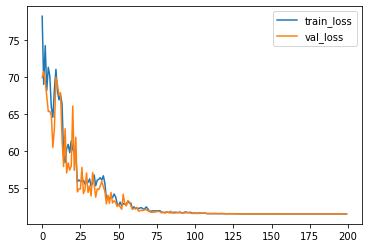

In [147]:
train_stats_df.plot()

Batch Losses

In [148]:
batch_losses_df = pd.DataFrame(batch_losses, columns=['Batch Loss'])
display(pd.DataFrame(batch_losses_df.T))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249
Batch Loss,66.753181,51.063244,56.07962,56.390053,45.832294,54.566593,51.102581,58.267902,47.481178,50.760101,45.927567,52.9958,45.940269,63.253242,49.764439,48.158737,54.741955,54.497513,52.170433,65.947166,55.534096,51.256176,52.841614,53.407734,54.605602,45.159492,57.419914,53.472176,58.023849,41.039806,46.258751,49.525898,54.210423,56.179073,51.2883,60.262669,55.065872,43.012154,44.815308,52.09861,...,52.014328,51.787411,52.791031,59.166885,47.36248,47.076664,47.037914,48.19199,54.385983,58.348225,53.457146,52.751598,58.075794,55.072327,56.274109,47.530758,51.487473,49.317047,51.374222,49.628498,51.40844,52.504307,46.638481,57.368767,57.830799,57.340744,46.874119,48.448231,56.430199,55.659527,46.125492,48.866558,49.449562,55.67408,56.16193,49.326912,44.530453,51.557274,54.055519,50.83519


Graphic representation of batch losses

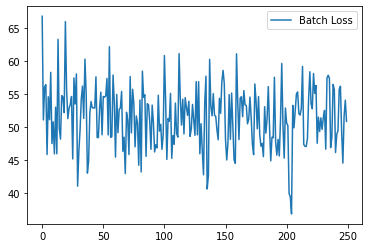

In [149]:
batch_losses_df.plot()

Save model

In [112]:
PATH = '/content/drive/MyDrive/University/Vaccine Sentiment Dataset/modelGlove'
torch.save({
            'epoch': 4,
            'model_state_dict': modelFF.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': float(batch_losses_df['Batch Loss'].tail(1)),
            }, PATH)

### Prediction

Model prediction for the test data.

In [150]:
prediction = []
y_actual = []
y_test = []
batch_num = 0.0

modelFF.eval()
accuracy = 0.0
f1 = 0.0
recall = 0.0
precision = 0.0
metrics = {'accuracy':0.0,
           'f1':0.0,
           'recall':0.0,
           'precision':0.0}

for val_batch in test_iter:
  
  batch_num += 1
  batch_prediction = []
  y_batch = []

  test_pred = modelFF(val_batch.tweet.T)
  test_label_pred = getPrediction(test_pred, 3)

  test_pred = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_actual = np.array(val_batch.label.cpu().flatten().detach().tolist())

  batch_prediction = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_batch = np.array(val_batch.label.cpu().flatten().detach().tolist())

  prediction.append(test_label_pred.tolist())
  y_test.append(val_batch.label.cpu().flatten().detach().tolist())

  #Compute the scores.
  accuracy += accuracy_score(y_batch, batch_prediction)
  f1 += f1_score(y_batch, batch_prediction, average='micro')
  recall += recall_score(y_batch, batch_prediction, average='micro')
  precision += precision_score(y_batch, batch_prediction, average='micro')

prediction = sum(prediction, [])
y_test = sum(y_test, [])


metrics['accuracy'] = accuracy/batch_num
metrics['f1'] = f1/batch_num
metrics['recall'] = recall/batch_num
metrics['precision'] = precision/batch_num

In [151]:
display(pd.DataFrame(pd.Series(metrics)).T)

,accuracy,f1,recall,precision
0,0.490079,0.490079,0.490079,0.490079


Classification report for the prediction made with the test data. (Model is previously trained with the vocabulary provided by the train data)

It is obvious that the prediction does not fair well in this case too...
However this outcome is somewhat expected since the train dataset is considered small to train a model of this kind and be satisfied with the prediction results.

In [152]:
model_report = classification_report(y_test,prediction)
print(model_report)

              precision    recall  f1-score   support

           0       0.53      0.62      0.57      1065
           1       0.27      0.08      0.13       296
           2       0.46      0.46      0.46       921

    accuracy                           0.49      2282
   macro avg       0.42      0.39      0.39      2282
weighted avg       0.47      0.49      0.47      2282



### ROC-Curve

([Receiver operating characteristic](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html))

From the curve it is obvious that the False positive rate in classes 0 and 1 (neutral and anti-vax) is quite high.

On the other hand, the model makes good enough (can always get better), predictions for class 2 (pro-vax).

All things considered, model tuning cannot always save the day. From a point after, especially in the case of neural networks, it is important to "feed" our network with a lots of data so that it can enhance its learning. Of course that does not enclose the cases where the model overfits.

In [153]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

y = label_binarize(y_actual, classes=[0, 1, 2])
n_classes = y.shape[1]

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_actual, test_pred, pos_label=i)
  roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_actual.ravel(), test_pred.ravel(), pos_label=2)
roc_auc_micro = auc(fpr["micro"], tpr["micro"])

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  


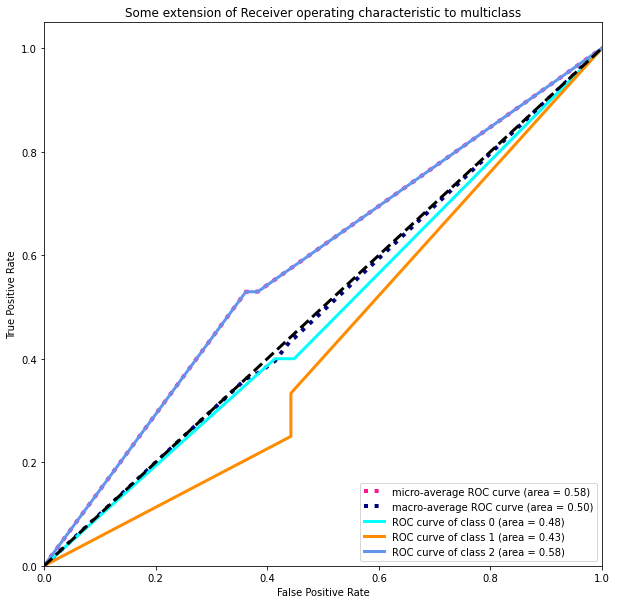

In [154]:
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
lw = 3

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc_macro = auc(fpr["macro"], tpr["macro"])

data={"macro":roc_auc_macro, "micro":roc_auc_micro}
roc_auc_t = pd.Series(data=data, index=["macro", "micro"])

# Plot all ROC curves
plt.figure(figsize=(10,10))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc_t["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc_t["macro"]),
    color="navy",
    linestyle=":",
    linewidth=4,
)


colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for i, color in zip(range(n_classes), colors):
  plt.plot(
      fpr[i],
      tpr[i],
      color=color,
      lw=lw,
      label="ROC curve of class {0} (area = {1:0.2f})".format(i, roc_auc[(i)]),
  )

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Some extension of Receiver operating characteristic to multiclass")
plt.legend(loc="lower right")
plt.show()